In [31]:
import pandas as pd
import numpy as np
import re
training_data_df = pd.read_csv("training_data_202601.csv")

# extract the training/validation tuples
ids = np.loadtxt("trainval_ids.txt", dtype=[("id", "i4")])
trainval_df = training_data_df[training_data_df["unique_id"].isin(ids["id"])]

f_clocks_df = trainval_df[trainval_df['Painting'] == 'The Persistence of Memory']
f_starry_df = trainval_df[trainval_df['Painting'] == 'The Starry Night']
f_lilies_df = trainval_df[trainval_df['Painting'] == 'The Water Lily Pond']

paintings = ['clocks', 'starry', 'lilies']
dfs = [f_clocks_df, f_starry_df, f_lilies_df]

In [11]:
output_files = []
for painting in paintings:
    output_files.append(("Describe how this painting makes you feel.", f'text/{painting}_feel.txt'))
    output_files.append(("If this painting was a food, what would be?", f'text/{painting}_food.txt'))
    output_files.append(("Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.", f'text/{painting}_soundtrack.txt'))
try:
    # Validate column existence
    for column_name, output_file in output_files:
        if "clocks" in output_file:
            df = f_clocks_df
        elif "starry" in output_file:
            df = starry_df
        else:
            df = lilies_df
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' does not exist in DataFrame.")

        # Export column to text file (one value per line)
        df[column_name].to_csv(output_file, index=False, header=False)

except (IOError, OSError) as file_error:
    print(f"File error: {file_error}")
except ValueError as val_error:
    print(f"Value error: {val_error}")
except Exception as e:
    print(f"Unexpected error: {e}")

In [12]:
from PIL import Image

clocks_coloring = np.array(Image.open("images/clocks.png"))
starry_coloring = np.array(Image.open("images/starry.png"))
lilies_coloring = np.array(Image.open("images/lilies.png"))
colorings = [clocks_coloring, starry_coloring, lilies_coloring]

In [18]:
# words to ignore for each question
general_ignore = [
    'clock', # should we ignore this one? Great predictor of one painting
    'clocks',
    'sky',
    'night' # same for these
    'something'
]

feel_ignore = [
    'feeling',
    'feelings',
    'feels',
    'felt'
]

food_ignore = [
    'foods'
]

music_ignore = [
    'sound',
    'sounds',
    'soundtracks',
    'music',
    'song'
]

{'yourselves', 'as', 'only', 'i', 'no', 'so', 'this', 'www', "she'd", 'all', 'you', 'shall', 'just', "they'll", 'own', "weren't", 'your', "we'd", 'for', "how's", "mustn't", "it's", "you've", 'most', "didn't", 'a', 'over', "haven't", "shouldn't", "he's", 'the', 'under', 'each', "that's", 'cannot', 'he', 'down', 'because', "aren't", 'both', 'what', 'further', "why's", "when's", "they're", 'or', 'up', 'their', 'how', 'himself', 'me', 'myself', 'him', 'on', 'to', "i'll", "he'll", 'be', 'k', 'she', 'out', 'them', "we're", 'during', "couldn't", 'does', 'her', 'into', 'ourselves', 'having', 'by', "he'd", "won't", "where's", 'an', 'before', "i'm", 'am', 'other', 'there', 'but', "isn't", "i'd", 'otherwise', "she's", 'in', 'few', 'ours', 'of', "we've", 'not', "there's", "you'd", 'and', 'ought', 'doing', 'between', 'did', 'than', "they've", 'herself', "you'll", "you're", 'com', 'should', 'been', "she'll", 'hence', "we'll", 'at', 'such', 'theirs', 'http', 'again', 'some', 'my', 'else', 'against', 

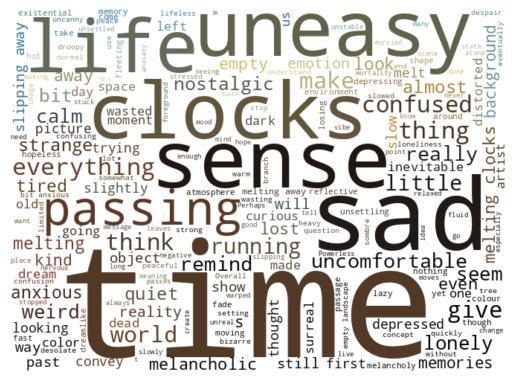

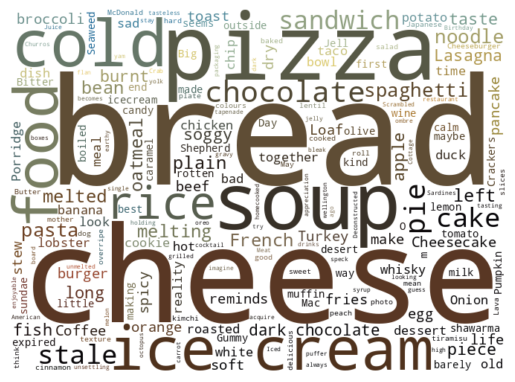

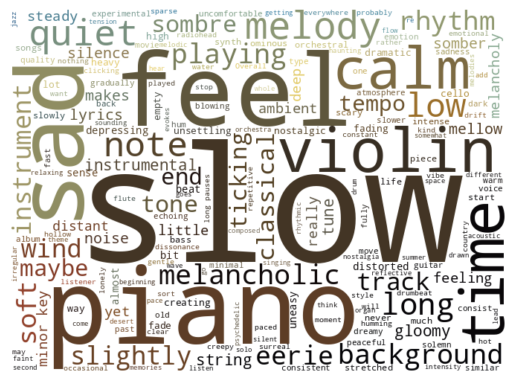

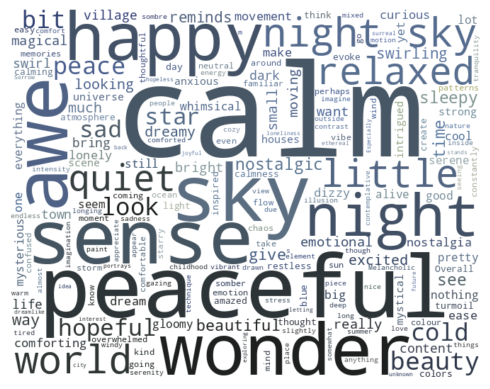

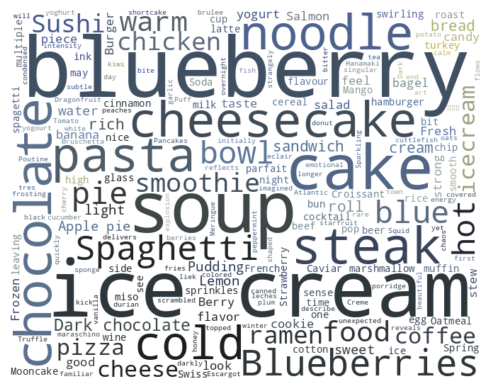

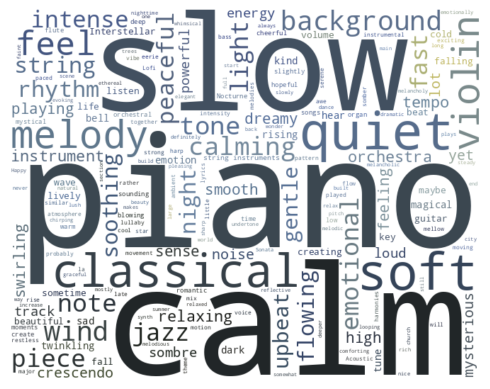

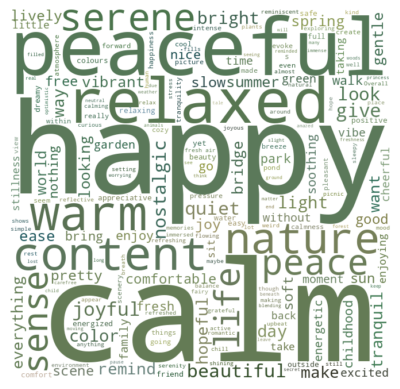

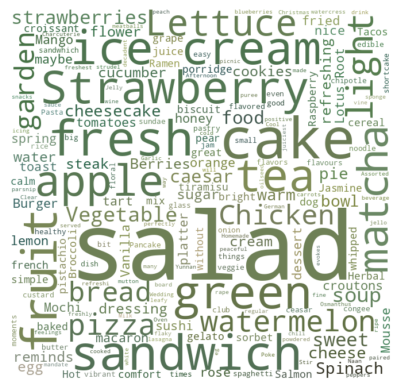

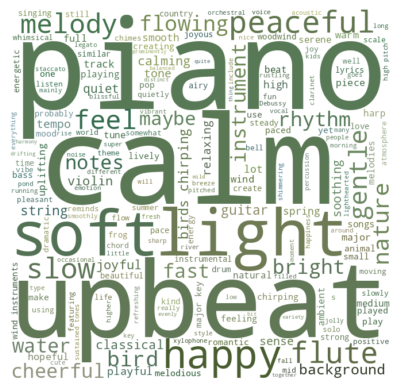

In [16]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

for column_name, output_file in output_files:
    if "clocks" in output_file:
        coloring = clocks_coloring
    elif "starry" in output_file:
        coloring = starry_coloring
    else:
        coloring = lilies_coloring

    stopwords = set(WordCloud().stopwords)
    stopwords.update(general_ignore)
    for word in column_name.strip('.,!?()[]{}"\'').split():
        stopwords.add(word)
    if "feel" in column_name:
        stopwords.update(feel_ignore)
    elif "food" in column_name:
        stopwords.update(food_ignore)
    else:
        stopwords.update(music_ignore)

    with open(output_file, 'r') as file:
        text = file.read()
        wordcloud = WordCloud(stopwords=stopwords, mask=coloring, background_color='white').generate(text)

    image_colors = ImageColorGenerator(coloring)

    plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
    plt.axis("off")
    plt.show()

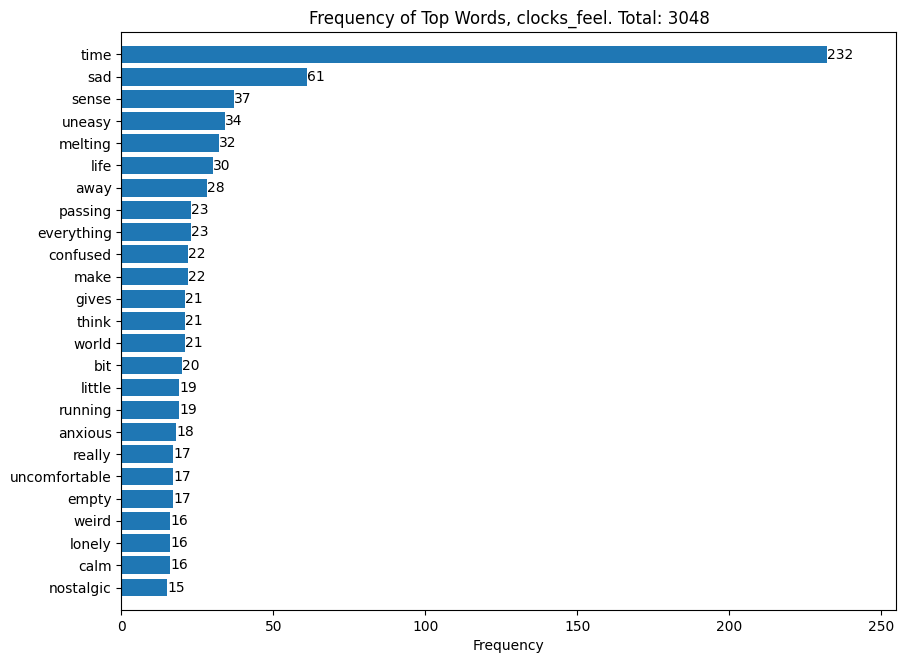

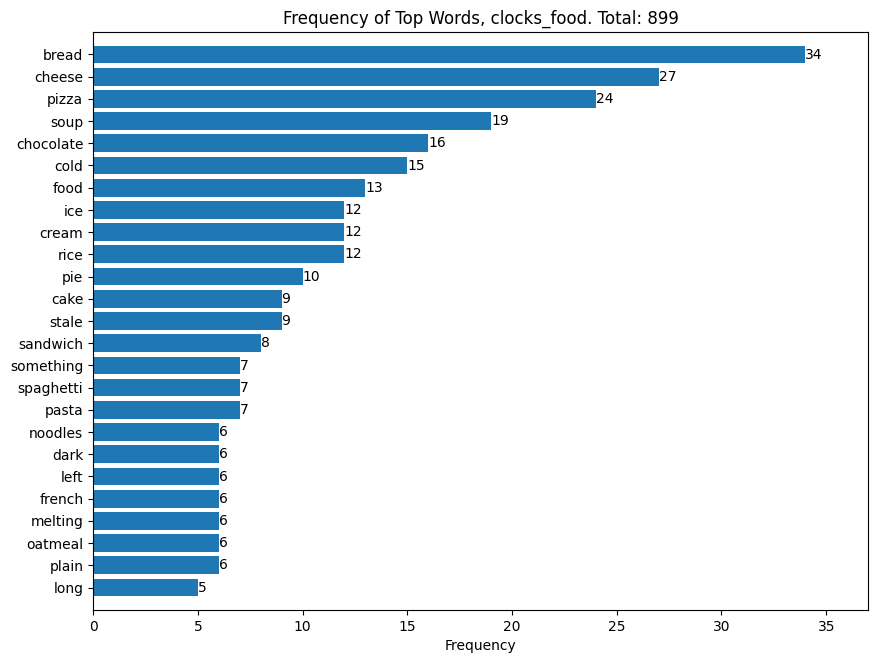

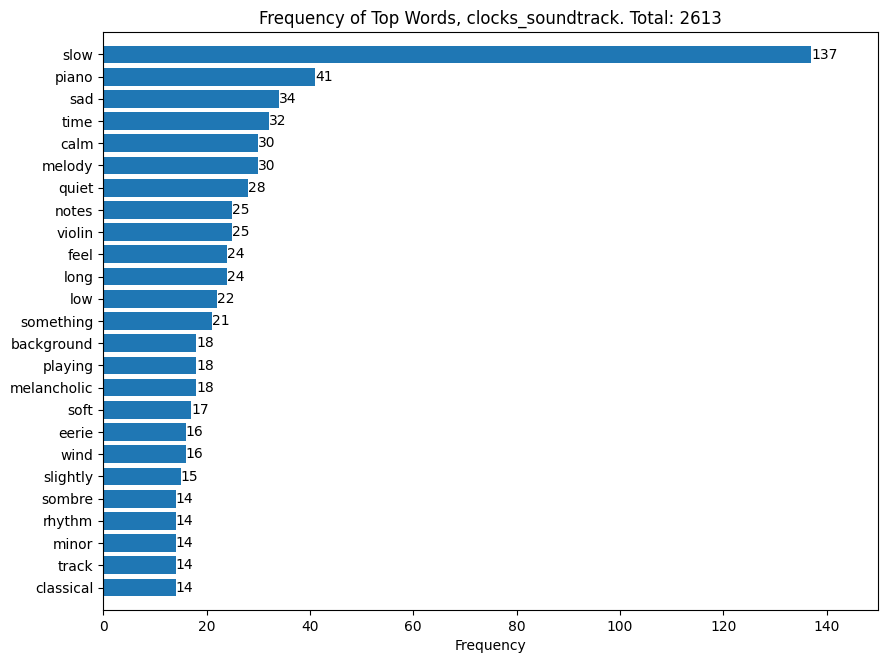

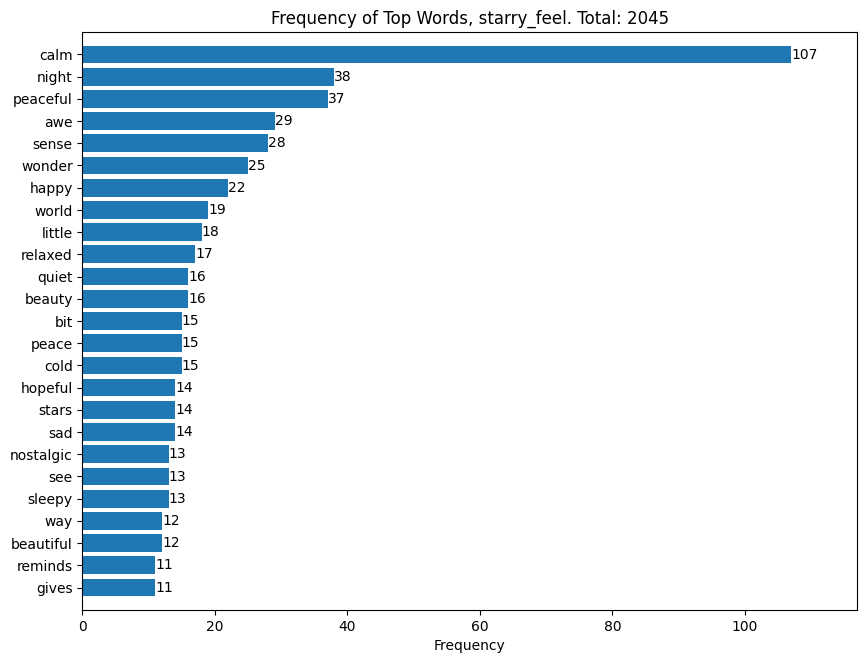

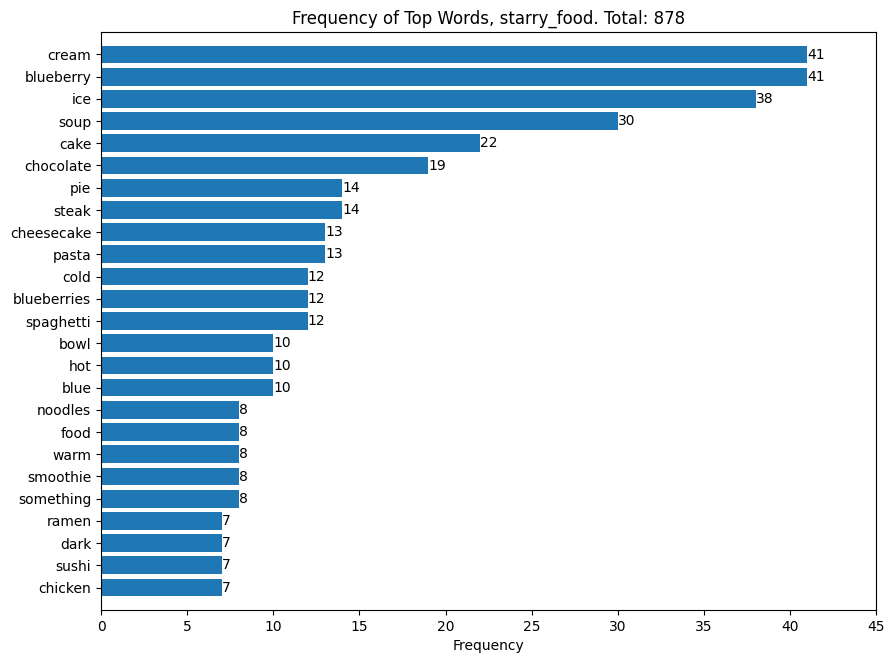

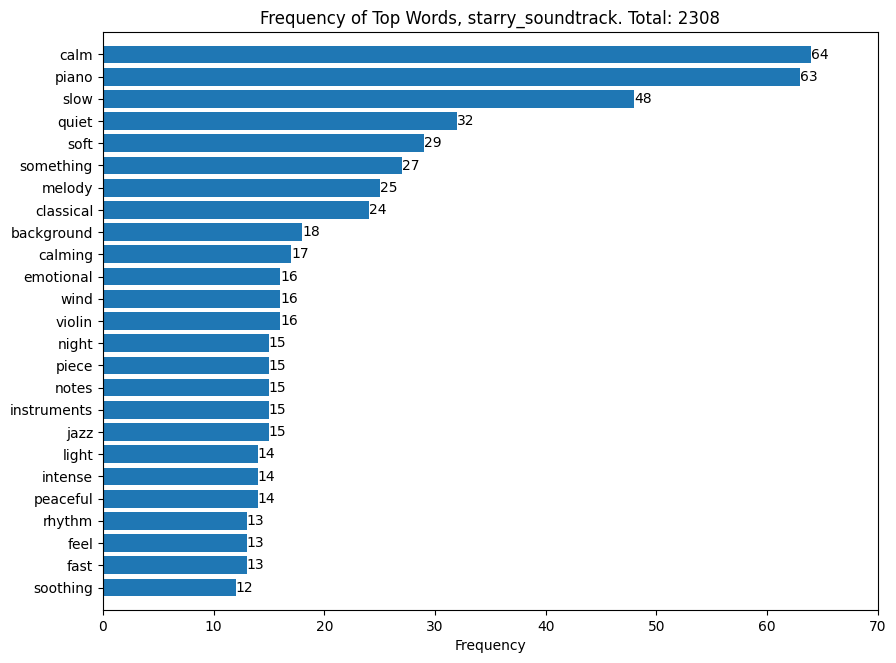

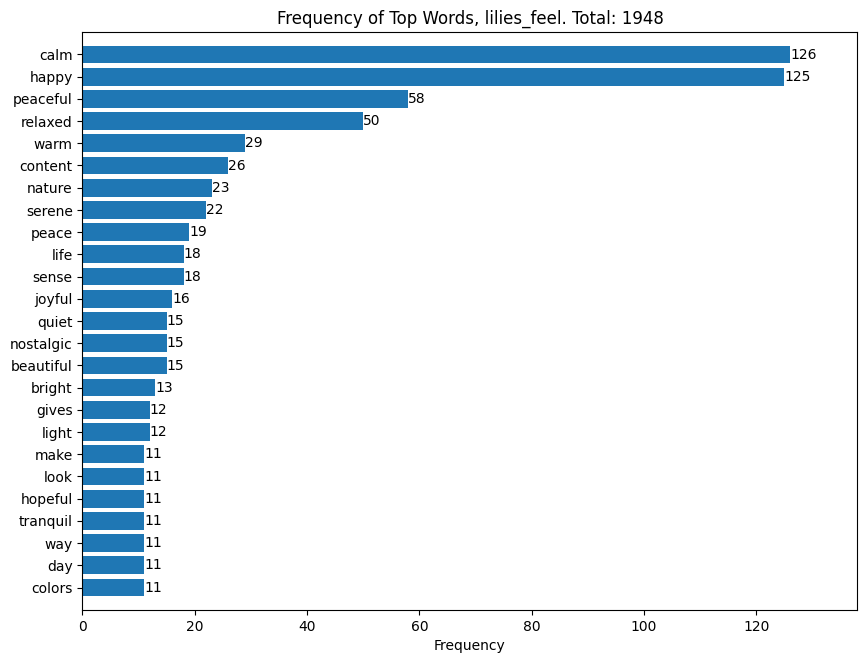

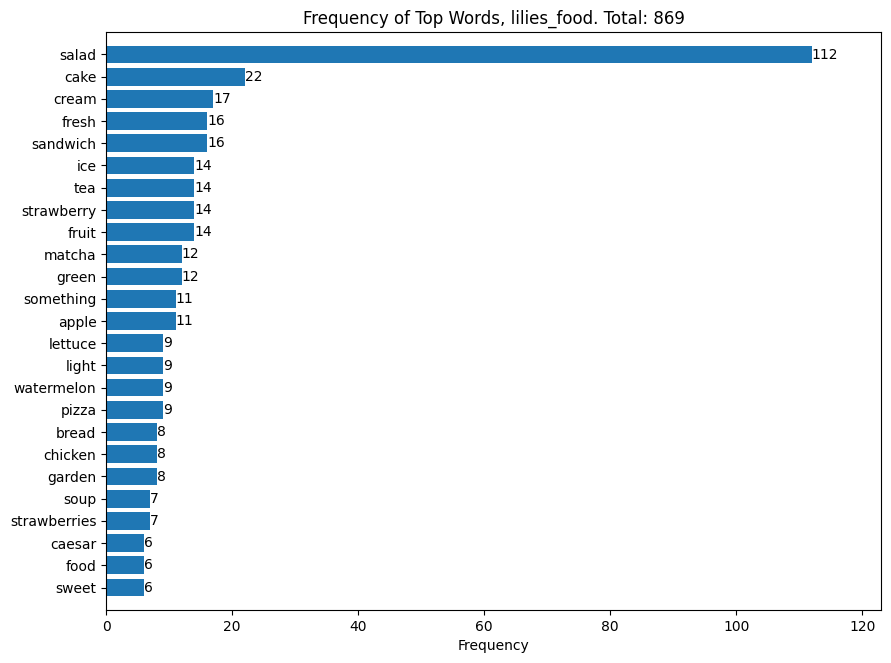

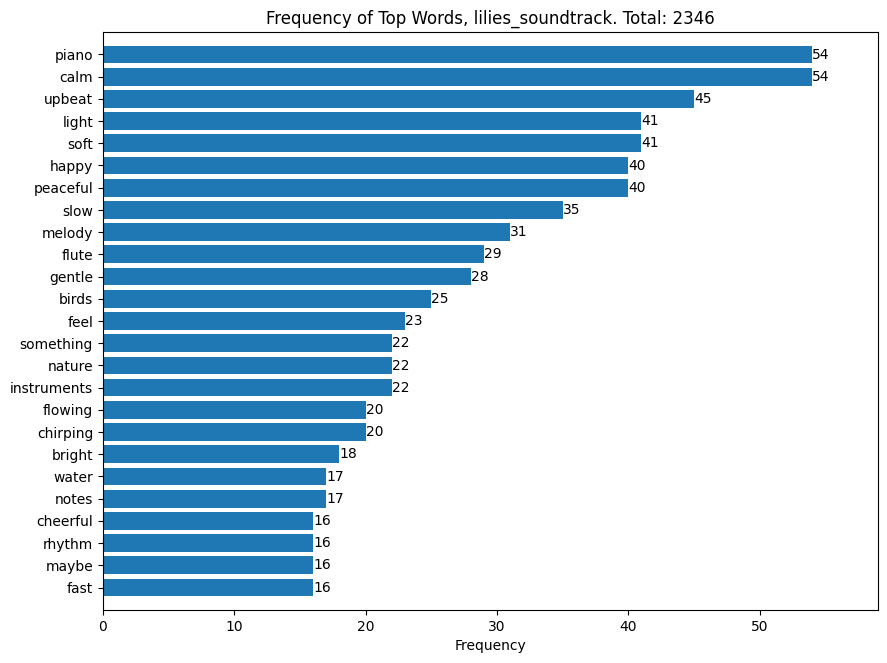

In [50]:
# create some histograms showing the most common words
base = set(['yourselves', 'as', 'only', 'i', 'no', 'so', 'this', 'www', "shed", 'all', 'you', 'shall', 'just', "theyll", 'own', "werent", 'your', "wed", 'for', "hows", "mustnt", "its", "youve", 'most', "didnt", 'a', 'over', "havent", "shouldnt", "hes", 'the', 'under', 'each', "thats", 'cannot', 'he', 'down', 'because', "arent", 'both', 'what', 'further', "whys", "whens", "theyre", 'or', 'up', 'their', 'how', 'himself', 'me', 'myself', 'him', 'on', 'to', "ill", "hell", 'be', 'k', 'she', 'out', 'them', "were", 'during', "couldnt", 'does', 'her', 'into', 'ourselves', 'having', 'by', "hed", "wont", "wheres", 'an', 'before', "im", 'am', 'other', 'there', 'but', "isnt", "id", 'otherwise', "shes", 'in', 'few', 'ours', 'of', "weve", 'not', "theres", "youd", 'and', 'ought', 'doing', 'between', 'did', 'than', "theyve", 'herself', "youll", "youre", 'com', 'should', 'been', "shell", 'hence', "well", 'at', 'such', 'theirs', 'http', 'again', 'some', 'my', 'else', 'against', "hadnt", "heres", "whats", 'more', 'below', 'any', 'after', 'these', 'off', "doesnt", 'can', 'who', "theyd", 'from', 'here', 'why', 'was', 'very', 'with', 'therefore', 'like', 'had', 'has', 'nor', 'its', 'those', "wouldnt", 'which', 'same', "wasnt", 'itself', 'would', 'above', 'while', 'when', 'however', 'is', 'our', 'where', 'yours', 'about', 'if', 'through', 'since', 'ever', 'do', 'themselves', 'r', "cant", 'have', 'also', 'hers', 'we', 'until', 'it', 'whom', 'could', 'get', 'yourself', 'too', "dont", "lets", 'being', "whos", "ive", 'were', "shant", 'are', 'then', "hasnt", 'once', 'they', 'his', 'that'])
N = 25

for column_name, output_file in output_files:
  painting = re.search(r"text/([^/]+)\.txt", output_file).group(1)

  stopwords = set(base)
  stopwords.update(general_ignore)
  for word in column_name.strip('.,!?()[]{}"\'').split():
    stopwords.add(word)

  if "feel" in column_name:
    stopwords.update(feel_ignore)
  elif "food" in column_name:
    stopwords.update(food_ignore)
  else:
    stopwords.update(music_ignore)

  counts = dict()
  total = 0
  with open(output_file, 'r') as file:
    for line in file:
      for w in line.split():
        w_clean = re.sub(r"[^\w\s]", "", w.strip().lower())
        if w_clean in stopwords or w_clean == '':
          continue

        if w_clean not in counts:
          counts[w_clean] = 0
        counts[w_clean] += 1
        total += 1
  # take the top N words
  counts_lst = list(counts.items())
  top_counts = sorted(counts_lst, reverse=True, key=lambda it: it[1])[:N]
  words = [c[0] for c in top_counts]
  nums = [c[1] for c in top_counts]
  xs = np.arange(N)

  fig_height = 0.3 * N
  fig, ax = plt.subplots(figsize=(10, fig_height))

  bar = ax.barh(xs, nums, height=0.8, align='center')
  ax.set_yticks(xs, labels=words)
  ax.set_ylim(-1, N)
  ax.invert_yaxis()
  ax.set_xlabel('Frequency')
  ax.set_title(f'Frequency of Top Words, {painting}. Total: {total}')

  ax.bar_label(bar, fmt='%d')
  ax.set_xlim(right=int(nums[0] * 1.1))
  plt.show()


